<a href="https://colab.research.google.com/github/Sertyron/AnalisisDeReviewEnVideojuegos/blob/main/AnalisisReview.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Vamos a usar mi muestreo de reseñas para ver como queda el NLP si hacemos las cosas bien

# **Recursos a Importar**

In [ ]:
#Importar Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Importar Todos los Data frame

# Este es el Data frame Original
!gdown 1hQgW2gPTvnJp5R7fp0yqfwKWSwOVg6CQ
!gdown 1friNh64ngAfQNeQ_laafriJnmI7xEPQh

Downloading...
From: https://drive.google.com/uc?id=1hQgW2gPTvnJp5R7fp0yqfwKWSwOVg6CQ
To: /content/Data_Muestra2.xlsx
100% 12.9k/12.9k [00:00<00:00, 3.69MB/s]
Downloading...
From: https://drive.google.com/uc?id=1friNh64ngAfQNeQ_laafriJnmI7xEPQh
To: /content/Data_Reseña2.xlsx
100% 1.73M/1.73M [00:00<00:00, 18.6MB/s]


In [ ]:
#Asociar la ruta a una variable
df_mustraTotal = pd.read_excel('/content/Data_Muestra2.xlsx')
df_reviews_total = pd.read_excel('/content/Data_Reseña2.xlsx')

# **Como queda sin hacer cambios el NLP**



In [ ]:
df_reviews_total.head()

,recommendationid,author,language,review,timestamp_created,timestamp_updated,voted_up,votes_up,votes_funny,weighted_vote_score,comment_count,steam_purchase,received_for_free,written_during_early_access,primarily_steam_deck,appid,timestamp_dev_responded,developer_response
0,208778276,"{'steamid': '76561198769955331', 'num_games_ow...",english,Gambling simulator with cheaters and guns! Bes...,1762666445,1763957182,True,485,135,0.913510,23,True,False,False,False,730,NaN,NaN
1,211640921,"{'steamid': '76561198081237360', 'num_games_ow...",english,Click heads = satisfying . \r\nClick anything ...,1764421285,1764421285,True,69,17,0.838050,9,True,False,False,False,730,NaN,NaN
2,211128320,"{'steamid': '76561199251091395', 'num_games_ow...",english,gold gold gold!\ni love gambling but if i open...,1764240795,1764240795,True,47,11,0.762419,9,True,False,False,False,730,NaN,NaN
3,209783078,"{'steamid': '76561199471545860', 'num_games_ow...",english,this game contains way too many stupid russian...,1763749266,1763749266,True,45,9,0.727317,0,True,False,False,False,730,NaN,NaN
4,208642194,"{'steamid': '76561198770614871', 'num_games_ow...",english,Quotation forthcoming.\n\nEDIT:\n\nCounter-Str...,1762533011,1764941428,True,19,0,0.680331,1,True,False,False,False,730,NaN,NaN


Accuracy: 0.8809766022380467

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.93      0.65      0.77       297
           1       0.87      0.98      0.92       686

    accuracy                           0.88       983
   macro avg       0.90      0.82      0.84       983
weighted avg       0.89      0.88      0.87       983



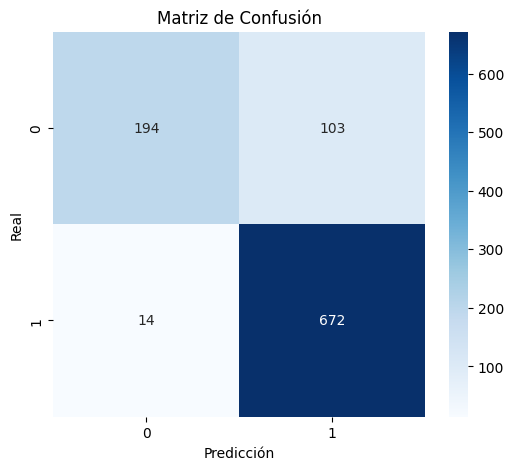

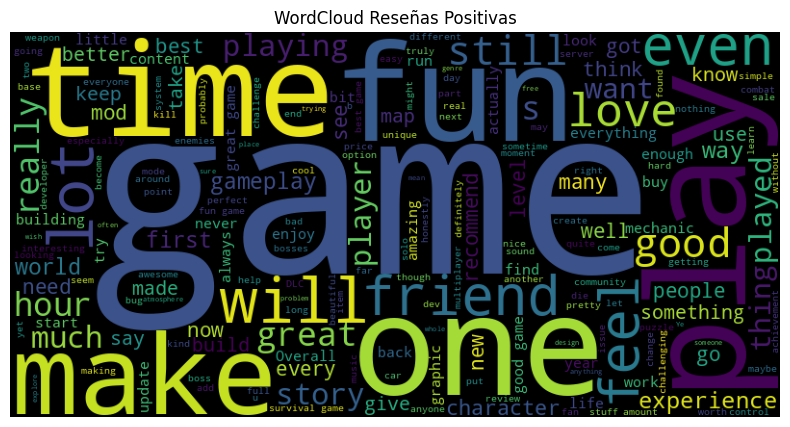

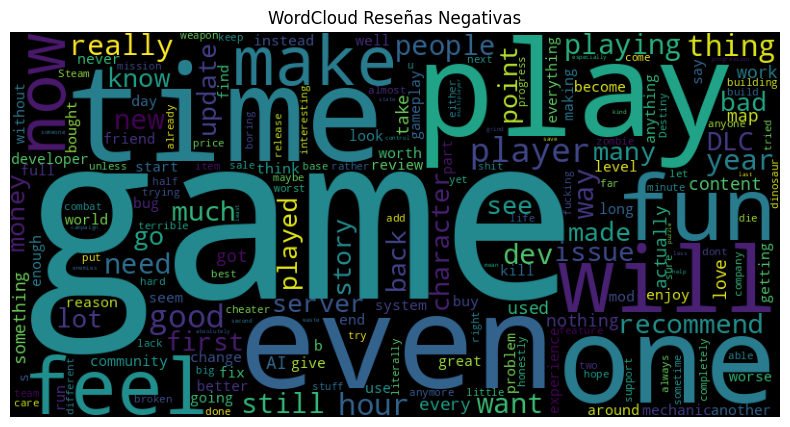

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Filtrado recomendado ---
df = df_reviews_total.copy()

df = df[df["review"].str.len() > 20]
df = df[df["steam_purchase"] == True]

# Convert 'weighted_vote_score' to numeric, coercing errors to NaN
df["weighted_vote_score"] = pd.to_numeric(df["weighted_vote_score"], errors='coerce')
# Now filter out NaNs and then apply the condition
df = df.dropna(subset=["weighted_vote_score"])
df = df[df["weighted_vote_score"] > 0]

X = df["review"]
y = df["voted_up"].astype(int)

# --- 2. Train-test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- 3. TF-IDF ---
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=20000,
    ngram_range=(1, 2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# --- 4. Modelo ---
model = LogisticRegression(max_iter=500)
model.fit(X_train_tfidf, y_train)

# --- 5. Predicciones ---
y_pred = model.predict(X_test_tfidf)

# --- 6. Métricas ---
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReporte de Clasificación:\n", classification_report(y_test, y_pred))

# --- 7. Matriz de confusión ---
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

# --- 8. WordCloud Positivo ---
positive_reviews = " ".join(df[df["voted_up"]==1]["review"])
wordcloud_pos = WordCloud(width=800, height=400).generate(positive_reviews)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_pos)
plt.axis("off")
plt.title("WordCloud Reseñas Positivas")
plt.show()

# --- 9. WordCloud Negativo ---
negative_reviews = " ".join(df[df["voted_up"]==0]["review"])
wordcloud_neg = WordCloud(width=800, height=400).generate(negative_reviews)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_neg)
plt.axis("off")
plt.title("WordCloud Reseñas Negativas")
plt.show()

## Proceso correcto del Procesamiento del Lenguaje Natural (PLN) O NLtk en ingles

In [ ]:
df_NLP = df_reviews_total.copy()

In [ ]:
df_NLP

,recommendationid,author,language,review,timestamp_created,timestamp_updated,voted_up,votes_up,votes_funny,weighted_vote_score,comment_count,steam_purchase,received_for_free,written_during_early_access,primarily_steam_deck,appid,timestamp_dev_responded,developer_response
0,208778276,"{'steamid': '76561198769955331', 'num_games_ow...",english,Gambling simulator with cheaters and guns! Bes...,1762666445,1763957182,True,485,135,0.913510,23,True,False,False,False,730,NaN,NaN
1,211640921,"{'steamid': '76561198081237360', 'num_games_ow...",english,Click heads = satisfying . \r\nClick anything ...,1764421285,1764421285,True,69,17,0.838050,9,True,False,False,False,730,NaN,NaN
2,211128320,"{'steamid': '76561199251091395', 'num_games_ow...",english,gold gold gold!\ni love gambling but if i open...,1764240795,1764240795,True,47,11,0.762419,9,True,False,False,False,730,NaN,NaN
3,209783078,"{'steamid': '76561199471545860', 'num_games_ow...",english,this game contains way too many stupid russian...,1763749266,1763749266,True,45,9,0.727317,0,True,False,False,False,730,NaN,NaN
4,208642194,"{'steamid': '76561198770614871', 'num_games_ow...",english,Quotation forthcoming.\n\nEDIT:\n\nCounter-Str...,1762533011,1764941428,True,19,0,0.680331,1,True,False,False,False,730,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4950,32080918,"{'steamid': '76561198188515021', 'num_games_ow...",english,Like Centipede but bad.\nNot bad meaning bad\n...,1496220459,1496220459,True,2,0,0.454197,0,True,False,False,False,447950,NaN,NaN
4951,47192162,"{'steamid': '76561198169811581', 'num_games_ow...",english,It's sorta like Space Invaders but a bit more ...,1543514123,1543514123,True,2,0,0.460277,0,True,False,False,False,447950,NaN,NaN
4952,29413529,"{'steamid': '76561198054387451', 'num_games_ow...",english,Short-lived...like a CATERPILLAR UNDER MY SHOE...,1485058955,1485058955,True,0,0,0.500000,0,True,False,False,False,447950,NaN,NaN
4953,93086769,"{'steamid': '76561199042140510', 'num_games_ow...",english,i am nerd....came hard for some reason,1622694992,1622694992,True,0,0,0.500000,0,True,False,False,False,447950,NaN,NaN


In [ ]:
# Visualizamos algunas de las reviews.

# La número 49
print(df_NLP.loc[50, 'review'])
print("\n" + "-"*80 + "\n")  # línea separadora


# La número 300
print(df_NLP.loc[301, 'review'])
print("\n" + "-"*80 + "\n")  # línea separadora


# La número 4954 (última fila)
print(df_NLP.loc[4954, 'review'])
print("\n" + "-"*80 + "\n")  # línea separadora

Nice game

--------------------------------------------------------------------------------

Meh, doesn't hold up to current times. I set up a personal server to play it because I'm not a PvP fan, was pretty easy to do but it wasn't all it's cracked up to be.

--------------------------------------------------------------------------------

I am 32 years old.

My ex-wife and I have a daughter together, and we adopted our son together. Both are now 4 years old.

When we were going through our separation, I felt lost and unhappy. I was self-destructive. One day, I was so angry with everything spiraling out of control that I punched a concrete wall in a moment of overwhelming emotion. This resulted in breaking my fifth metacarpal in my right hand—the hand I worked with, played games with, and used to carry my children to bed—the hand I desperately needed to ensure I could continue providing.

Upon learning the severity of the self-inflicted damage, I became almost suicidal. Keep in mind t

# Normalizar Datos

In [ ]:
# Guardamos todas las columnas excepto "review"
cols = [col for col in df_NLP.columns if col != "review"]

# Reordenamos poniendo "review" al final
df_NLP = df_NLP[cols + ["review"]]

In [ ]:
#  ¿Qué hace .lower()? Convierte todo el texto a minúsculas.

# No necesitás importar ninguna librería para usar .lower(), ya que es un método incorporado en los objetos de tipo str en Python.
# Esto significa que cualquier texto (cadena de caracteres) puede convertirse a minúsculas directamente con .lower().
#  Es útil para normalizar texto antes de analizarlo o procesarlo.
df_NLP['review_lower'] = df_NLP['review'].apply(lambda text: text.lower())


In [ ]:
df_NLP

,recommendationid,author,language,timestamp_created,timestamp_updated,voted_up,votes_up,votes_funny,weighted_vote_score,comment_count,steam_purchase,received_for_free,written_during_early_access,primarily_steam_deck,appid,timestamp_dev_responded,developer_response,review_lower,review
0,208778276,"{'steamid': '76561198769955331', 'num_games_ow...",english,1762666445,1763957182,True,485,135,0.913510,23,True,False,False,False,730,NaN,NaN,gambling simulator with cheaters and guns! bes...,Gambling simulator with cheaters and guns! Bes...
1,211640921,"{'steamid': '76561198081237360', 'num_games_ow...",english,1764421285,1764421285,True,69,17,0.838050,9,True,False,False,False,730,NaN,NaN,click heads = satisfying . \r\nclick anything ...,Click heads = satisfying . \r\nClick anything ...
2,211128320,"{'steamid': '76561199251091395', 'num_games_ow...",english,1764240795,1764240795,True,47,11,0.762419,9,True,False,False,False,730,NaN,NaN,gold gold gold!\ni love gambling but if i open...,gold gold gold!\ni love gambling but if i open...
3,209783078,"{'steamid': '76561199471545860', 'num_games_ow...",english,1763749266,1763749266,True,45,9,0.727317,0,True,False,False,False,730,NaN,NaN,this game contains way too many stupid russian...,this game contains way too many stupid russian...
4,208642194,"{'steamid': '76561198770614871', 'num_games_ow...",english,1762533011,1764941428,True,19,0,0.680331,1,True,False,False,False,730,NaN,NaN,quotation forthcoming.\n\nedit:\n\ncounter-str...,Quotation forthcoming.\n\nEDIT:\n\nCounter-Str...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4950,32080918,"{'steamid': '76561198188515021', 'num_games_ow...",english,1496220459,1496220459,True,2,0,0.454197,0,True,False,False,False,447950,NaN,NaN,like centipede but bad.\nnot bad meaning bad\n...,Like Centipede but bad.\nNot bad meaning bad\n...
4951,47192162,"{'steamid': '76561198169811581', 'num_games_ow...",english,1543514123,1543514123,True,2,0,0.460277,0,True,False,False,False,447950,NaN,NaN,it's sorta like space invaders but a bit more ...,It's sorta like Space Invaders but a bit more ...
4952,29413529,"{'steamid': '76561198054387451', 'num_games_ow...",english,1485058955,1485058955,True,0,0,0.500000,0,True,False,False,False,447950,NaN,NaN,short-lived...like a caterpillar under my shoe...,Short-lived...like a CATERPILLAR UNDER MY SHOE...
4953,93086769,"{'steamid': '76561199042140510', 'num_games_ow...",english,1622694992,1622694992,True,0,0,0.500000,0,True,False,False,False,447950,NaN,NaN,i am nerd....came hard for some reason,i am nerd....came hard for some reason


In [ ]:
import re

# Definir una función que remueva los signos de puntuación usando re
def remove_punctuation(text):
    # Expresión regular para reemplazar cualquier signo de puntuación o símbolo no alfanumérico
     return re.sub(r'[^a-zA-Z0-9\s]', '', text)

# Aplicar la función a la columna 'review_lower'
df_NLP['review_puntuacion'] = df_NLP['review_lower'].apply(remove_punctuation)

In [ ]:
df_NLP.head(5)

,recommendationid,author,language,timestamp_created,timestamp_updated,voted_up,votes_up,votes_funny,weighted_vote_score,comment_count,steam_purchase,received_for_free,written_during_early_access,primarily_steam_deck,appid,timestamp_dev_responded,developer_response,review_lower,review,review_puntuacion
0,208778276,"{'steamid': '76561198769955331', 'num_games_ow...",english,1762666445,1763957182,True,485,135,0.913510,23,True,False,False,False,730,NaN,NaN,gambling simulator with cheaters and guns! bes...,Gambling simulator with cheaters and guns! Bes...,gambling simulator with cheaters and guns best...
1,211640921,"{'steamid': '76561198081237360', 'num_games_ow...",english,1764421285,1764421285,True,69,17,0.838050,9,True,False,False,False,730,NaN,NaN,click heads = satisfying . \r\nclick anything ...,Click heads = satisfying . \r\nClick anything ...,click heads satisfying \r\nclick anything el...
2,211128320,"{'steamid': '76561199251091395', 'num_games_ow...",english,1764240795,1764240795,True,47,11,0.762419,9,True,False,False,False,730,NaN,NaN,gold gold gold!\ni love gambling but if i open...,gold gold gold!\ni love gambling but if i open...,gold gold gold\ni love gambling but if i open ...
3,209783078,"{'steamid': '76561199471545860', 'num_games_ow...",english,1763749266,1763749266,True,45,9,0.727317,0,True,False,False,False,730,NaN,NaN,this game contains way too many stupid russian...,this game contains way too many stupid russian...,this game contains way too many stupid russian...
4,208642194,"{'steamid': '76561198770614871', 'num_games_ow...",english,1762533011,1764941428,True,19,0,0.680331,1,True,False,False,False,730,NaN,NaN,quotation forthcoming.\n\nedit:\n\ncounter-str...,Quotation forthcoming.\n\nEDIT:\n\nCounter-Str...,quotation forthcoming\n\nedit\n\ncounterstrike...


## Tokenizacion de palabras

In [ ]:
# Importamos las librerías necesarias
import nltk

nltk.download('punkt')  # Descargamos el paquete de tokenización de NLTK
nltk.download('punkt_tab')  # Descargamos el paquete de tokenización de NLTK
from nltk.tokenize import word_tokenize # Desde el módulo nltk.tokenize, quiero importar solo la función word_tokenize

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
# Tokenizamos los valores de la columna 'review'
df_NLP['review_tokenizado'] = df_NLP['review_puntuacion'].apply(word_tokenize)


In [ ]:
# Configuramos pandas para mostrar el contenido completo de las columnas
pd.set_option('display.max_colwidth', None)

In [ ]:
# Mostramos las primeras filas con la columna original y de la columna tokenizada
df_NLP[['review', 'review_tokenizado']].head()

,review,review_tokenizado
0,Gambling simulator with cheaters and guns! Best FPS game out there despite glaring issues.,"[gambling, simulator, with, cheaters, and, guns, best, fps, game, out, there, despite, glaring, issues]"
1,Click heads = satisfying . \r\nClick anything else = dog sh1t game,"[click, heads, satisfying, click, anything, else, dog, sh1t, game]"
2,gold gold gold!\ni love gambling but if i open up one more case and dont get a knife im jumping o0ff a bridge (hypothetically),"[gold, gold, gold, i, love, gambling, but, if, i, open, up, one, more, case, and, dont, get, a, knife, im, jumping, o0ff, a, bridge, hypothetically]"
3,this game contains way too many stupid russians but atleast its fun to play sometimes,"[this, game, contains, way, too, many, stupid, russians, but, atleast, its, fun, to, play, sometimes]"
4,"Quotation forthcoming.\n\nEDIT:\n\nCounter-Strike 2’s wall of noise and violence will feel impenetrable to newcomers but a welcome upgrade for long-term Counter-Strike fans. It’s the best competitive shooter on the market, but it’s so difficult for new players to get on board that it won’t be for everyone.","[quotation, forthcoming, edit, counterstrike, 2s, wall, of, noise, and, violence, will, feel, impenetrable, to, newcomers, but, a, welcome, upgrade, for, longterm, counterstrike, fans, its, the, best, competitive, shooter, on, the, market, but, its, so, difficult, for, new, players, to, get, on, board, that, it, wont, be, for, everyone]"


In [ ]:
# Restauramos la configuración predeterminada de pandas para el ancho de las columnas
pd.reset_option('display.max_colwidth')

## Quitar las Stopword o palabras conectoras

In [ ]:
# Previsualizamos algunas stopwords previstas en la librería.

import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords

# Obtenemos el listado de stopwords en español
stopwords_eng = stopwords.words('english')

# Mostramos las primeras 20
print(stopwords_eng[:20])

[nltk_data] Downloading package stopwords to /root/nltk_data...


['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been']


[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
# Importamos stopwords de NLTK (Pueden importarse tanto para español como para inglés)
nltk.download('stopwords') # Descargamos el paquete de stopwords de NLTK para poder usarlas en el código
from nltk.corpus import stopwords # Importamos el módulo de stopwords desde NLTK, que contiene listas de palabras vacías

# Lista de stopwords en inglés
stop_words = set(stopwords.words('english')) # Creamos un conjunto de stopwords en inglés usando NLTK

# Función para eliminar stopwords de los tokens
# Aplicamos una función lambda a cada fila de la columna 'review_tokenizado'
df_NLP['review_tokenizado_sin_stopwords'] = df_NLP['review_tokenizado'].apply(lambda tokens: [word for word in tokens if word not in stop_words])
    # La función lambda toma cada lista de tokens (palabras tokenizadas de la reseña),
    # y devuelve una nueva lista donde solo quedan las palabras que no están en la lista de stopwords.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


El uso de palabras cortadas

In [ ]:
# Importar el PorterStemmer de nltk
from nltk.stem import PorterStemmer

# Inicializar el stemmer
stemmer = PorterStemmer()

# Aplicar stemming a la columna 'review_tokenizado_sin_stopwords'
df_NLP['review_stemming'] = df_NLP['review_tokenizado_sin_stopwords'].apply(lambda tokens: [stemmer.stem(token) for token in tokens])


Las palabras compuestas de ingles Ejem Get out

In [ ]:
#Importamos librerías

import nltk
nltk.download('wordnet')  # Base de datos léxica de WordNet para lematización en inglés

# Importar el WordNetLemmatizer de nltk
from nltk.stem import WordNetLemmatizer

# Inicializar el lematizador
lemmatizer = WordNetLemmatizer()

# Aplicar la lematización a la columna 'review_tokenizado_sin_stopwords'
df_NLP['review_lematizacion'] = df_NLP['review_tokenizado_sin_stopwords'].apply(lambda tokens: [lemmatizer.lemmatize(token) for token in tokens])

[nltk_data] Downloading package wordnet to /root/nltk_data...


##Resultado final

In [ ]:
df_NLP.head(15)

,recommendationid,author,language,timestamp_created,timestamp_updated,voted_up,votes_up,votes_funny,weighted_vote_score,comment_count,...,appid,timestamp_dev_responded,developer_response,review_lower,review,review_puntuacion,review_tokenizado,review_tokenizado_sin_stopwords,review_stemming,review_lematizacion
0,208778276,"{'steamid': '76561198769955331', 'num_games_ow...",english,1762666445,1763957182,True,485,135,0.913510,23,...,730,NaN,NaN,gambling simulator with cheaters and guns! bes...,Gambling simulator with cheaters and guns! Bes...,gambling simulator with cheaters and guns best...,"[gambling, simulator, with, cheaters, and, gun...","[gambling, simulator, cheaters, guns, best, fp...","[gambl, simul, cheater, gun, best, fp, game, d...","[gambling, simulator, cheater, gun, best, fps,..."
1,211640921,"{'steamid': '76561198081237360', 'num_games_ow...",english,1764421285,1764421285,True,69,17,0.838050,9,...,730,NaN,NaN,click heads = satisfying . \r\nclick anything ...,Click heads = satisfying . \r\nClick anything ...,click heads satisfying \r\nclick anything el...,"[click, heads, satisfying, click, anything, el...","[click, heads, satisfying, click, anything, el...","[click, head, satisfi, click, anyth, els, dog,...","[click, head, satisfying, click, anything, els..."
2,211128320,"{'steamid': '76561199251091395', 'num_games_ow...",english,1764240795,1764240795,True,47,11,0.762419,9,...,730,NaN,NaN,gold gold gold!\ni love gambling but if i open...,gold gold gold!\ni love gambling but if i open...,gold gold gold\ni love gambling but if i open ...,"[gold, gold, gold, i, love, gambling, but, if,...","[gold, gold, gold, love, gambling, open, one, ...","[gold, gold, gold, love, gambl, open, one, cas...","[gold, gold, gold, love, gambling, open, one, ..."
3,209783078,"{'steamid': '76561199471545860', 'num_games_ow...",english,1763749266,1763749266,True,45,9,0.727317,0,...,730,NaN,NaN,this game contains way too many stupid russian...,this game contains way too many stupid russian...,this game contains way too many stupid russian...,"[this, game, contains, way, too, many, stupid,...","[game, contains, way, many, stupid, russians, ...","[game, contain, way, mani, stupid, russian, at...","[game, contains, way, many, stupid, russian, a..."
4,208642194,"{'steamid': '76561198770614871', 'num_games_ow...",english,1762533011,1764941428,True,19,0,0.680331,1,...,730,NaN,NaN,quotation forthcoming.\n\nedit:\n\ncounter-str...,Quotation forthcoming.\n\nEDIT:\n\nCounter-Str...,quotation forthcoming\n\nedit\n\ncounterstrike...,"[quotation, forthcoming, edit, counterstrike, ...","[quotation, forthcoming, edit, counterstrike, ...","[quotat, forthcom, edit, counterstrik, 2s, wal...","[quotation, forthcoming, edit, counterstrike, ..."
5,212041886,"{'steamid': '76561199797065377', 'num_games_ow...",english,1764525066,1764525066,True,22,12,0.679784,5,...,730,NaN,NaN,rly good game \nfree rusian lesions\nin each t...,rly good game \nfree rusian lesions\nin each t...,rly good game \nfree rusian lesions\nin each t...,"[rly, good, game, free, rusian, lesions, in, e...","[rly, good, game, free, rusian, lesions, team,...","[rli, good, game, free, rusian, lesion, team, ...","[rly, good, game, free, rusian, lesion, team, ..."
6,209851015,"{'steamid': '76561199038041256', 'num_games_ow...",english,1763824239,1763824239,True,25,5,0.672832,2,...,730,NaN,NaN,this game ruins your life but still the best g...,This game ruins your life but still the best g...,this game ruins your life but still the best g...,"[this, game, ruins, your, life, but, still, th...","[game, ruins, life, still, best, game, history...","[game, ruin, life, still, best, game, histori,...","[game, ruin, life, still, best, game, history,..."
7,208597290,"{'steamid': '76561199146203316', 'num_games_ow...",english,1762477838,1762477859,False,31,1,0.670191,0,...,730,NaN,NaN,"it's impossible to play in dm, there are only ...","It's impossible to play in DM, there are only ...",its impossible to play in

#**Analisis**

Palabras con mayor frecuencia

In [ ]:
from collections import Counter

stopwords_personalizadas = {"game", "play", "player"}

tokens_filtrados = [
    token
    for tokens_list in df_NLP['review_lematizacion']
    for token in tokens_list
    if token not in stopwords_personalizadas
]

frecuencia_palabras_lematizadas = Counter(tokens_filtrados)

frecuencia_palabras_lematizadas.most_common(20)

[('like', 2194),
 ('time', 1736),
 ('fun', 1703),
 ('get', 1656),
 ('one', 1613),
 ('good', 1441),
 ('even', 1269),
 ('dont', 1116),
 ('make', 1093),
 ('feel', 1080),
 ('really', 1057),
 ('hour', 921),
 ('great', 903),
 ('much', 878),
 ('playing', 850),
 ('would', 849),
 ('still', 832),
 ('thing', 822),
 ('new', 808),
 ('lot', 801)]

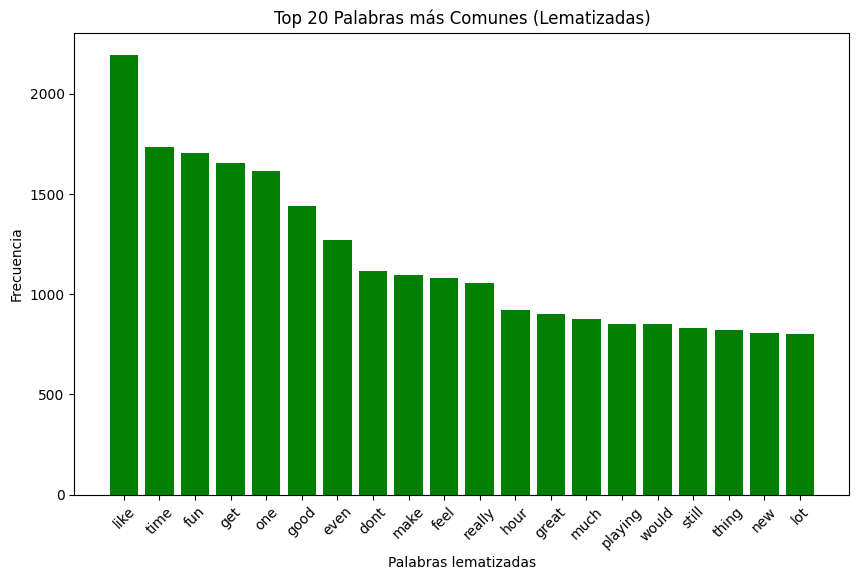

In [ ]:
# Importamos matplotlib para la visualización
import matplotlib.pyplot as plt

# Obtenemos las 20 palabras más comunes y sus frecuencias
palabras_lem, frecuencias_lem = zip(*frecuencia_palabras_lematizadas.most_common(20))

# Creamos el gráfico de barras
plt.figure(figsize=(10, 6))  # Ajustamos el tamaño del gráfico
plt.bar(palabras_lem, frecuencias_lem, color='green')

# Añadimos etiquetas y título
plt.xlabel('Palabras lematizadas')
plt.ylabel('Frecuencia')
plt.title('Top 20 Palabras más Comunes (Lematizadas)')

# Rotamos las etiquetas del eje X para que se lean mejor
plt.xticks(rotation=45)

# Mostramos el gráfico
plt.show()

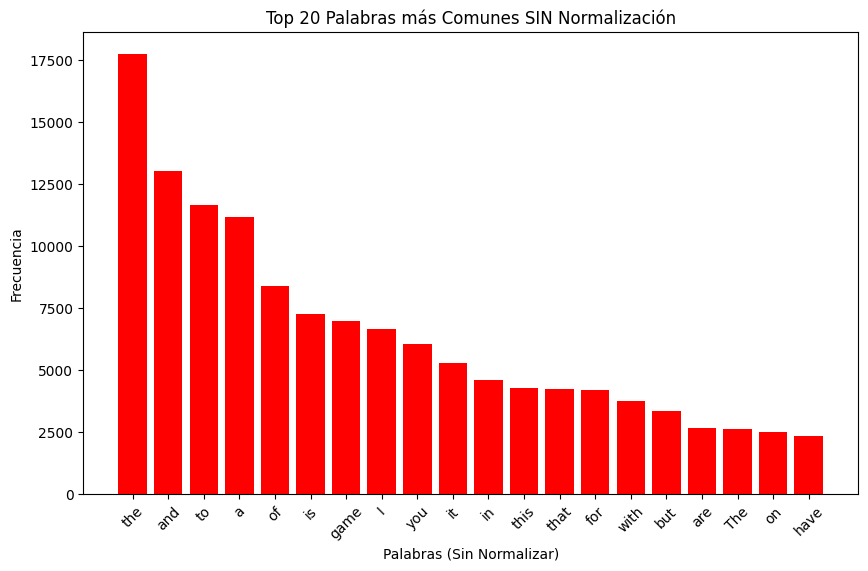

In [ ]:
# ¿Que hubiera pasado si creabamos este gráfico con los datos originales?
import matplotlib.pyplot as plt
from collections import Counter

# Tokenizamos sin normalizar (sin pasar a minúsculas, sin quitar puntuación)
tokens_sin_normalizar = [token for review in df_NLP['review'] for token in review.split()]

# Contamos la frecuencia de cada palabra
frecuencia_sin_normalizar = Counter(tokens_sin_normalizar)

# Obtenemos las 20 palabras más comunes y sus frecuencias
palabras_sin_norm, frecuencias_sin_norm = zip(*frecuencia_sin_normalizar.most_common(20))

# Creamos el gráfico de barras
plt.figure(figsize=(10, 6))
plt.bar(palabras_sin_norm, frecuencias_sin_norm, color='red')  # Color rojo para marcar que está "mal"

# Añadimos etiquetas y título
plt.xlabel('Palabras (Sin Normalizar)')
plt.ylabel('Frecuencia')
plt.title('Top 20 Palabras más Comunes SIN Normalización')

# Rotamos las etiquetas del eje X para que se lean mejor
plt.xticks(rotation=45)

# Mostramos el gráfico
plt.show()

# Nuves de palabras o WorldCloud

In [ ]:
# Importamos las librerías para crear una nube de palabras

from wordcloud import WordCloud
import matplotlib.pyplot as plt

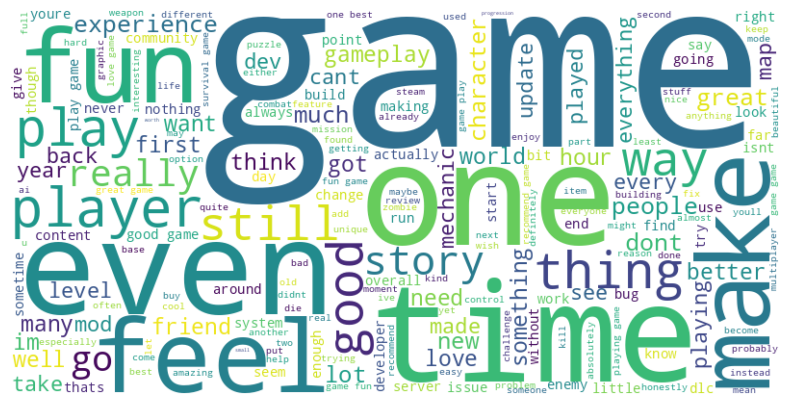

In [ ]:
# Unir todo el texto de la columna 'review_es'

#Esto es necesario porque la WordCloud genera la nube de palabras a partir de
# una única cadena de texto, y no puede procesar una columna de DataFrame directamente.

df_NLP['review_lematizacion_str'] = df_NLP['review_lematizacion'].apply(lambda x: " ".join(x))
text = " ".join(df_NLP['review_lematizacion_str'])

# Generar la WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
# Crea un objeto WordCloud con un ancho de 800 píxeles, altura de 400, y fondo blanco.
# El método 'generate' crea la nube de palabras a partir del texto dado.

# Mostrar la WordCloud
plt.figure(figsize=(10, 5))
# Crea una figura de tamaño 10x5 pulgadas para la visualización de la nube.

plt.imshow(wordcloud, interpolation='bilinear')
# Muestra la nube de palabras en la figura, usando interpolación bilineal para suavizarla.

plt.axis('off')
# Oculta los ejes de la figura para una mejor visualización.

plt.show()
# Muestra la figura en pantalla.

Accuracy: 0.8809766022380467

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.93      0.66      0.77       297
           1       0.87      0.98      0.92       686

    accuracy                           0.88       983
   macro avg       0.90      0.82      0.84       983
weighted avg       0.89      0.88      0.87       983



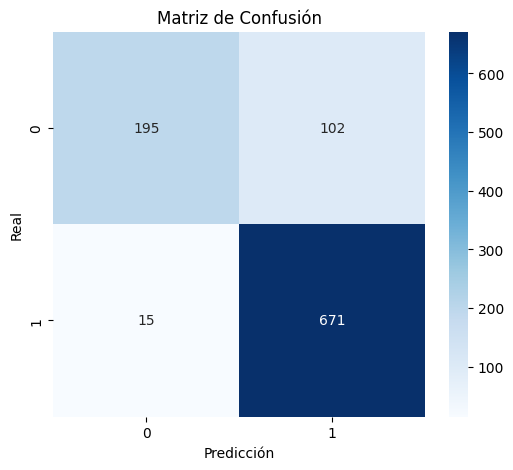

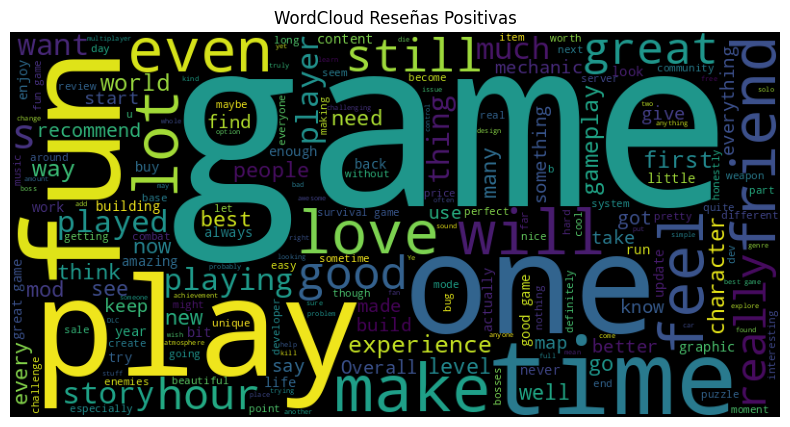

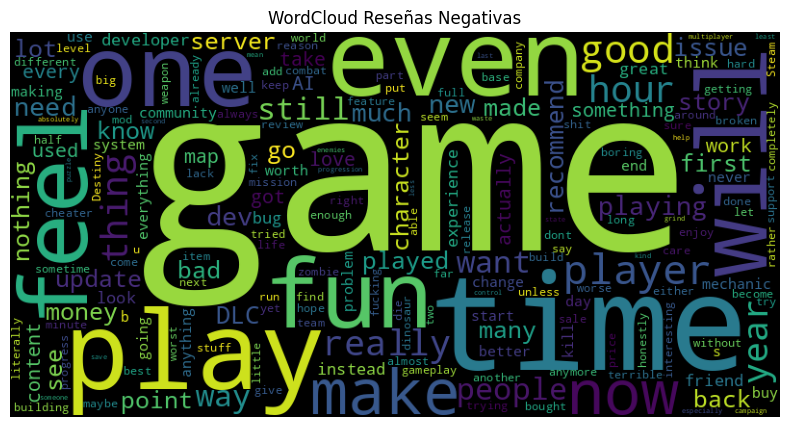

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Filtrado recomendado ---
df = df_NLP.copy()

df = df[df["review"].str.len() > 20]
df = df[df["steam_purchase"] == True]

# Convert 'weighted_vote_score' to numeric, coercing errors to NaN
df["weighted_vote_score"] = pd.to_numeric(df["weighted_vote_score"], errors='coerce')
# Now filter out NaNs and then apply the condition
df = df.dropna(subset=["weighted_vote_score"])
df = df[df["weighted_vote_score"] > 0]
df["review_lematizacion_str"] = df["review_lematizacion"].apply(lambda x: " ".join(x))

X = df["review_lematizacion_str"]
y = df["voted_up"].astype(int)

# --- 2. Train-test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- 3. TF-IDF ---
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=20000,
    ngram_range=(1, 2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# --- 4. Modelo ---
model = LogisticRegression(max_iter=500)
model.fit(X_train_tfidf, y_train)

# --- 5. Predicciones ---
y_pred = model.predict(X_test_tfidf)

# --- 6. Métricas ---
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReporte de Clasificación:\n", classification_report(y_test, y_pred))

# --- 7. Matriz de confusión ---
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

# --- 8. WordCloud Positivo ---
positive_reviews = " ".join(df[df["voted_up"]==1]["review"])
wordcloud_pos = WordCloud(width=800, height=400).generate(positive_reviews)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_pos)
plt.axis("off")
plt.title("WordCloud Reseñas Positivas")
plt.show()

# --- 9. WordCloud Negativo ---
negative_reviews = " ".join(df[df["voted_up"]==0]["review"])
wordcloud_neg = WordCloud(width=800, height=400).generate(negative_reviews)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_neg)
plt.axis("off")
plt.title("WordCloud Reseñas Negativas")
plt.show()

In [ ]:
df["review_lematizacion_str"] = df["review_lematizacion"].apply(lambda x: " ".join(x))

In [ ]:
positive_reviews = " ".join(df[df["voted_up"]==1]["review"])

In [ ]:
stopwords_wc = {"game", "play", "player"}

wordcloud_pos = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=stopwords_wc
).generate(positive_text)

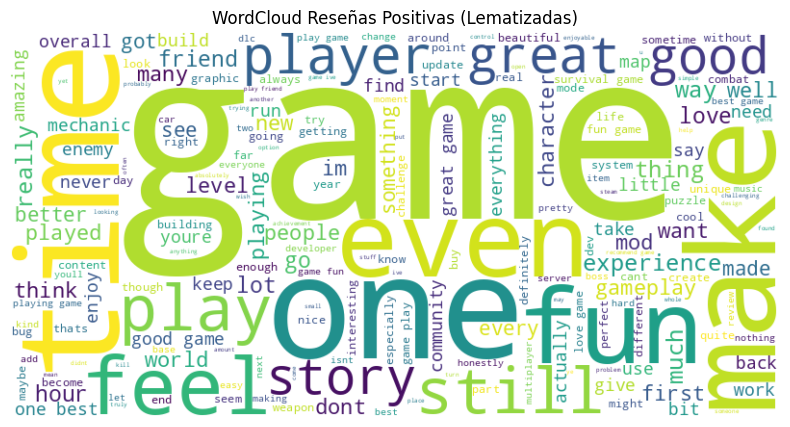

In [ ]:
positive_text = " ".join(df[df["voted_up"]==1]["review_lematizacion_str"])

wordcloud_pos = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis("off")
plt.title("WordCloud Reseñas Positivas (Lematizadas)")
plt.show()

In [ ]:
negative_reviews = " ".join(df[df["voted_up"]==0]["review"])

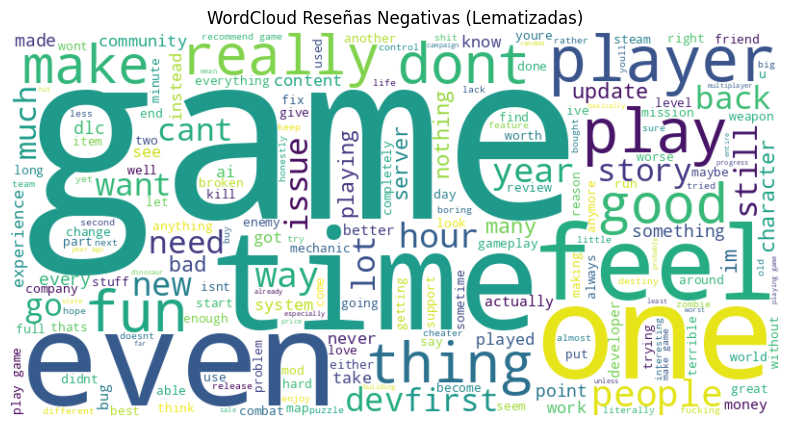

In [ ]:
negative_text = " ".join(df[df["voted_up"]==0]["review_lematizacion_str"])

wordcloud_neg = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis("off")
plt.title("WordCloud Reseñas Negativas (Lematizadas)")
plt.show()

In [ ]:
X = df_NLP["review_lematizacion_str"]